### ANN for regression, Sales Prediction of Carseats

### THIS EXAMPLE CONTAINS A VERY COMMON OPTIMIZATION METHOD IN BASIC ANN REGRESSION - BatchNormalization and regularization, see the neural network structure part for details!

#### Imports / modules

In [95]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

#### Loading the dataset

In [96]:
# load the csv-file to pandas DataFrame
df = pd.read_csv("CarSeats.csv")

In [97]:
# deep learning / neural network-wise, this is a small dataset
len(df)

400

In [98]:
# quickly check the first few rows of data
# to see what we have here
df.head()

,No,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,5,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [99]:
# drop No field since it is not required
df.drop(columns=['No'], inplace=True)

In [100]:
print(df.dtypes)

Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc          str
Age              int64
Education        int64
Urban              str
US                 str
dtype: object


### Few more checks for data, any missing values or duplicates

In [101]:
# it seems we don't have any missing values
df.isna().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [102]:
# no duplicates either, it seems
int(df.duplicated().sum())

0

### Handling the variables

*Type 1: Boolean categories*

In [103]:
from sklearn.preprocessing import LabelEncoder

# list all variables that can be binary-converted
variables = ['Urban', 'US']

# load the encoder
encoder = LabelEncoder()

# convert the listed variables
df[variables] = df[variables].apply(encoder.fit_transform)

df.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,1,1
1,11.22,111,48,16,260,83,Good,65,10,1,1
2,10.06,113,35,10,269,80,Medium,59,12,1,1
3,7.40,117,100,4,466,97,Medium,55,14,1,1
4,4.15,141,64,3,340,128,Bad,38,13,1,0


In [104]:
# quick check that it worked
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,1,1
1,11.22,111,48,16,260,83,Good,65,10,1,1
2,10.06,113,35,10,269,80,Medium,59,12,1,1
3,7.40,117,100,4,466,97,Medium,55,14,1,1
4,4.15,141,64,3,340,128,Bad,38,13,1,0
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,1,1
396,6.14,139,23,3,37,120,Medium,55,11,0,1
397,7.41,162,26,12,368,159,Medium,40,18,1,1
398,5.94,100,79,7,284,95,Bad,50,12,1,1


*Type 2: Ordinal categories*

In [105]:
# Check value counts for ShelveLoc before modifying ordinal categories
df['ShelveLoc'].value_counts()

ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

In [106]:
# Map ShelveLoc - Ordinal categories
category_mapper = {
'Good': 2,
'Medium': 1,
'Bad': 0
}
df['ShelveLoc'] = df['ShelveLoc'].replace(category_mapper)


df['ShelveLoc'] = df['ShelveLoc'].astype(int)
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,2,65,10,1,1
2,10.06,113,35,10,269,80,1,59,12,1,1
3,7.40,117,100,4,466,97,1,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


*Type 3: Nominal categories*

In [108]:
# No Nominal Categories this time

#### X/y -split

In [109]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("Sales", axis=1)

# have only the target variable here (dependent variable)
y = df['Sales']

#### Train/test/validation -split

In [110]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

#### Create a neural network structure

In [111]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function

# let's try some common optimization approaches

# neural networks often need at least a normalization layer
# so that it updates all weight values fairly 
# typically the original dataset has various scales of numbers
# which confuses neural network while it's training itself
# luckily we have the BatchNormalization -layer in Keras!

# regularization is often beneficial in neural networks as well
# but Wit's usually better to apply this a bit later
# once you know approximately a working neural network structure for your data

# there are three alternatives for kernel regulaizer => L1, L2 and L1/L2
# you just have to experiment to know which regulazier best suits your model
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
# loss-function for regression is mse (mean squared error)
model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\Gayani\Deep_Learning\Deep_Learning\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305 (5.10 KB)

 Trainable params: 1,285 (5.02 KB)

 Non-trainable params: 20 (80.00 B)

#### Train the neural network

In [ ]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=1400, validation_data=(X_val, y_val))

Epoch 1/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 65.3817 - val_loss: 50.1201
Epoch 2/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 62.0377 - val_loss: 45.5370
Epoch 3/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 58.7253 - val_loss: 41.1884
Epoch 4/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 54.8020 - val_loss: 36.5439
Epoch 5/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 49.9414 - val_loss: 31.2225
Epoch 6/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 43.7794 - val_loss: 25.9298
Epoch 7/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 36.6302 - val_loss: 20.9772
Epoch 8/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28.8214 - val_loss: 17.3606
Epoch 9/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.1408 - val_loss: 15.5829
Epoch 10/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.0940 - val_loss: 15.5785
Epoch 11/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12.5417 - val_loss: 15.6617
Epoch 12/1400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/ste

#### Training metrics in order to see if the model trained an works well

<Axes: >

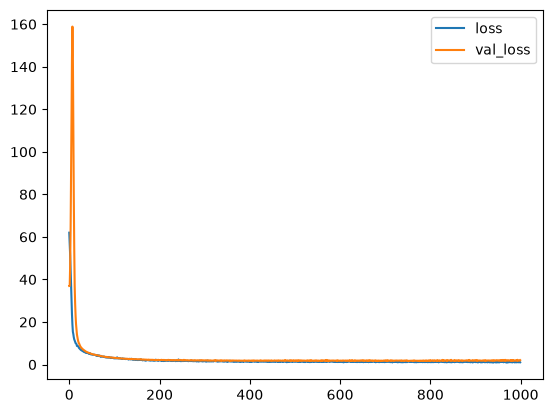

In [ ]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [ ]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
1.5866124629974365

Train data evaluation:
0.778702974319458


#### Error metrics

In [ ]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


,Test True Y,Model Predictions
0,11.54,9.258038
1,10.61,9.148171
2,2.66,2.191731
3,7.96,5.080758
4,8.32,7.790695
5,7.49,6.816564
6,8.67,7.933092
7,6.67,7.022655
8,6.67,8.755344
9,3.90,3.535374


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

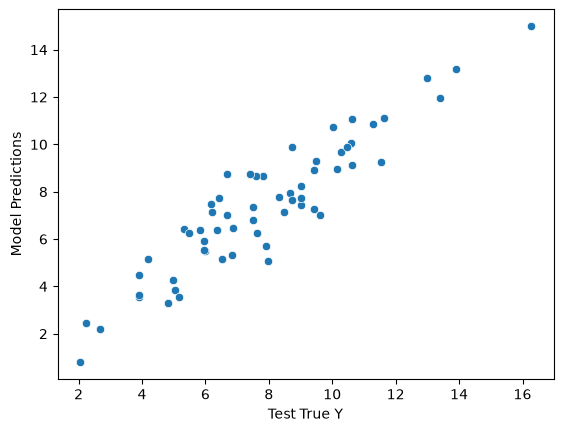

In [ ]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [ ]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
0.97 $

MSE
1.36 $^2

RMSE:
1.17 $

R-squared:
0.84

Explained variance score:
0.86


C:\Users\Gayani\AppData\Local\Temp\ipykernel_17784\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


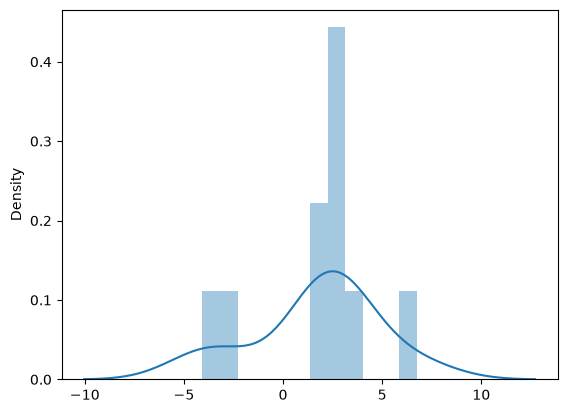

In [ ]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

#### Try model in practice (with a new imaginary house)

In [ ]:
# just to quickly check what support variables we should include
# in the tester_row -part below
X.columns

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='str')

In [ ]:
# print a few example houses so we can test with
# the tester row below
df.head(3)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,2,65,10,1,1
2,10.06,113,35,10,269,80,1,59,12,1,1


In [ ]:
# let's try with some new imaginary data
# this example uses the student performance index score dataset
# modify this as needed regarding your own dataset
tester_row = {
    'CompPrice': 120,
    'Income': 70,
    'Advertising': 10,
    'Population': 300,
    'Price': 100,
    'ShelveLoc': 2,   # encoded (Bad=0, Medium=1, Good=2)
    'Age': 50,
    'Education': 15,
    'Urban': 1,       # Yes=1, No=0
    'US': 1           # Yes=1, No=0
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [ ]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Predicted sales:")
print(f"$ {round(float(result[0]), 2)}")
print("----------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

Predicted sales:
$ 11.97
----------------
